# Exploración Dataset CoNLL-2002 (NER Español)

**Objetivo**: Análisis exploratorio del dataset CoNLL-2002 para Named Entity Recognition en español

**Dataset**: CoNLL-2002 Shared Task - Spanish NER
- **Entidades**: PER (Persona), LOC (Lugar), ORG (Organización), MISC (Miscelánea)
- **Formato**: BIO (B-entidad, I-entidad, O)
- **Splits**: train.txt, valid.txt, test.txt

**Tareas**:
1. Cargar y parsear datos en formato CoNLL
2. Análisis de distribución de entidades
3. Estadísticas de longitud de secuencias
4. Análisis de balance de clases
5. Visualizaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import json
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Configuración de Rutas

In [2]:
# Rutas del proyecto
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'datasets-taller' / 'datasets-taller' / 'conll2002'
RESULTS_DIR = BASE_DIR / 'resultados' / 'fase4_ner_bilstm'

# Crear directorio de resultados
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Archivos del dataset
TRAIN_FILE = DATA_DIR / 'train.txt'
VALID_FILE = DATA_DIR / 'valid.txt'
TEST_FILE = DATA_DIR / 'test.txt'

print(f'Dataset en: {DATA_DIR}')
print(f'Resultados en: {RESULTS_DIR}')
print(f'\nArchivos disponibles:')
print(f'  Train: {TRAIN_FILE.exists()}')
print(f'  Valid: {VALID_FILE.exists()}')
print(f'  Test: {TEST_FILE.exists()}')

Dataset en: ..\datasets-taller\datasets-taller\conll2002
Resultados en: ..\resultados\fase4_ner_bilstm

Archivos disponibles:
  Train: True
  Valid: True
  Test: True


## 2. Funciones de Carga de Datos

Formato CoNLL:
```
Melbourne NP B-LOC
( Fpa O
Australia NP B-LOC
) Fpt O

```
Cada línea: `palabra tag_pos tag_ner`  
Líneas vacías separan oraciones

In [3]:
def load_conll_file(filepath):
    """
    Carga archivo CoNLL-2002 y retorna lista de oraciones
    Cada oración es una lista de tuplas (palabra, pos_tag, ner_tag)
    """
    sentences = []
    current_sentence = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if not line:  # Línea vacía = fin de oración
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split()
                if len(parts) >= 3:  # palabra pos_tag ner_tag
                    word, pos_tag, ner_tag = parts[0], parts[1], parts[2]
                    current_sentence.append((word, pos_tag, ner_tag))
    
    # Agregar última oración si existe
    if current_sentence:
        sentences.append(current_sentence)
    
    return sentences

def extract_entities(sentence):
    """
    Extrae entidades nombradas de una oración en formato BIO
    Retorna lista de tuplas (entidad_texto, tipo_entidad)
    """
    entities = []
    current_entity = []
    current_type = None
    
    for word, _, ner_tag in sentence:
        if ner_tag.startswith('B-'):  # Begin de entidad
            # Guardar entidad anterior si existe
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
            # Empezar nueva entidad
            current_entity = [word]
            current_type = ner_tag[2:]  # Remover 'B-'
        
        elif ner_tag.startswith('I-'):  # Inside de entidad
            if current_entity and current_type == ner_tag[2:]:
                current_entity.append(word)
        
        else:  # O (Outside)
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
                current_entity = []
                current_type = None
    
    # Agregar última entidad si existe
    if current_entity:
        entities.append((' '.join(current_entity), current_type))
    
    return entities

print('Funciones de carga definidas correctamente')

Funciones de carga definidas correctamente


## 3. Cargar Datasets

In [4]:
print('Cargando datasets...')
train_sentences = load_conll_file(TRAIN_FILE)
valid_sentences = load_conll_file(VALID_FILE)
test_sentences = load_conll_file(TEST_FILE)

print(f'\nDatasets cargados:')
print(f'  Train: {len(train_sentences):,} oraciones')
print(f'  Valid: {len(valid_sentences):,} oraciones')
print(f'  Test: {len(test_sentences):,} oraciones')
print(f'  TOTAL: {len(train_sentences) + len(valid_sentences) + len(test_sentences):,} oraciones')

Cargando datasets...

Datasets cargados:
  Train: 8,323 oraciones
  Valid: 1,915 oraciones
  Test: 1,517 oraciones
  TOTAL: 11,755 oraciones


## 4. Ejemplo de Datos

In [5]:
# Mostrar primera oración del train
print('Ejemplo de oración (train):')
print('\nFormato: (palabra, pos_tag, ner_tag)\n')
for word, pos, ner in train_sentences[0][:15]:
    print(f'{word:20} {pos:10} {ner}')

# Extraer y mostrar entidades
print('\n' + '='*60)
print('Entidades encontradas en esta oración:')
entities = extract_entities(train_sentences[0])
for entity, ent_type in entities:
    print(f'  [{ent_type}] {entity}')

Ejemplo de oración (train):

Formato: (palabra, pos_tag, ner_tag)

Melbourne            NP         B-LOC
(                    Fpa        O
Australia            NP         B-LOC
)                    Fpt        O
,                    Fc         O
25                   Z          O
may                  NC         O
(                    Fpa        O
EFE                  NC         B-ORG
)                    Fpt        O
.                    Fp         O

Entidades encontradas en esta oración:
  [LOC] Melbourne
  [LOC] Australia
  [ORG] EFE


## 5. Análisis de Etiquetas NER

In [6]:
def get_ner_tags_stats(sentences):
    """
    Cuenta todas las etiquetas NER en un conjunto de oraciones
    """
    tag_counter = Counter()
    
    for sentence in sentences:
        for _, _, ner_tag in sentence:
            tag_counter[ner_tag] += 1
    
    return tag_counter

# Contar etiquetas en cada split
train_tags = get_ner_tags_stats(train_sentences)
valid_tags = get_ner_tags_stats(valid_sentences)
test_tags = get_ner_tags_stats(test_sentences)

# Crear DataFrame con estadísticas
all_tags = sorted(set(train_tags.keys()) | set(valid_tags.keys()) | set(test_tags.keys()))
tag_stats = pd.DataFrame({
    'Tag': all_tags,
    'Train': [train_tags[tag] for tag in all_tags],
    'Valid': [valid_tags[tag] for tag in all_tags],
    'Test': [test_tags[tag] for tag in all_tags]
})
tag_stats['Total'] = tag_stats['Train'] + tag_stats['Valid'] + tag_stats['Test']
tag_stats['Train_%'] = (tag_stats['Train'] / tag_stats['Train'].sum() * 100).round(2)

print('Distribución de Etiquetas NER:')
print(tag_stats.to_string(index=False))

# Guardar estadísticas
tag_stats.to_csv(RESULTS_DIR / 'conll2002_tag_distribution.csv', index=False)
print(f'\nEstadísticas guardadas en: {RESULTS_DIR / "conll2002_tag_distribution.csv"}')

Distribución de Etiquetas NER:
   Tag  Train  Valid  Test  Total  Train_%
 B-LOC   4913    984  1084   6981     1.86
B-MISC   2173    445   339   2957     0.82
 B-ORG   7390   1700  1400  10490     2.79
 B-PER   4321   1222   735   6278     1.63
 I-LOC   1891    337   325   2553     0.71
I-MISC   3212    654   557   4423     1.21
 I-ORG   4992   1366  1104   7462     1.89
 I-PER   3903    859   634   5396     1.47
     O 231920  45356 45355 322631    87.61

Estadísticas guardadas en: ..\resultados\fase4_ner_bilstm\conll2002_tag_distribution.csv


## 6. Análisis de Entidades por Tipo

In [7]:
def count_entities_by_type(sentences):
    """
    Cuenta entidades completas por tipo (no tokens individuales)
    """
    entity_counter = Counter()
    
    for sentence in sentences:
        entities = extract_entities(sentence)
        for _, ent_type in entities:
            entity_counter[ent_type] += 1
    
    return entity_counter

# Contar entidades completas
train_entities = count_entities_by_type(train_sentences)
valid_entities = count_entities_by_type(valid_sentences)
test_entities = count_entities_by_type(test_sentences)

# Crear DataFrame
entity_types = sorted(set(train_entities.keys()) | set(valid_entities.keys()) | set(test_entities.keys()))
entity_stats = pd.DataFrame({
    'Tipo_Entidad': entity_types,
    'Train': [train_entities[e] for e in entity_types],
    'Valid': [valid_entities[e] for e in entity_types],
    'Test': [test_entities[e] for e in entity_types]
})
entity_stats['Total'] = entity_stats['Train'] + entity_stats['Valid'] + entity_stats['Test']
entity_stats['Porcentaje'] = (entity_stats['Total'] / entity_stats['Total'].sum() * 100).round(2)

print('Distribución de Entidades Completas por Tipo:')
print(entity_stats.to_string(index=False))
print(f'\nTotal de entidades: {entity_stats["Total"].sum():,}')

# Guardar
entity_stats.to_csv(RESULTS_DIR / 'conll2002_entity_distribution.csv', index=False)
print(f'\nEstadísticas guardadas en: {RESULTS_DIR / "conll2002_entity_distribution.csv"}')

Distribución de Entidades Completas por Tipo:
Tipo_Entidad  Train  Valid  Test  Total  Porcentaje
         LOC   4913    984  1084   6981       26.14
        MISC   2173    445   339   2957       11.07
         ORG   7390   1700  1400  10490       39.28
         PER   4321   1222   735   6278       23.51

Total de entidades: 26,706

Estadísticas guardadas en: ..\resultados\fase4_ner_bilstm\conll2002_entity_distribution.csv


## 7. Análisis de Longitud de Secuencias

In [8]:
def get_sequence_lengths(sentences):
    """Retorna lista de longitudes de oraciones"""
    return [len(sent) for sent in sentences]

# Calcular longitudes
train_lengths = get_sequence_lengths(train_sentences)
valid_lengths = get_sequence_lengths(valid_sentences)
test_lengths = get_sequence_lengths(test_sentences)
all_lengths = train_lengths + valid_lengths + test_lengths

# Estadísticas descriptivas
length_stats = pd.DataFrame({
    'Dataset': ['Train', 'Valid', 'Test', 'Total'],
    'Min': [np.min(train_lengths), np.min(valid_lengths), np.min(test_lengths), np.min(all_lengths)],
    'Max': [np.max(train_lengths), np.max(valid_lengths), np.max(test_lengths), np.max(all_lengths)],
    'Mean': [np.mean(train_lengths), np.mean(valid_lengths), np.mean(test_lengths), np.mean(all_lengths)],
    'Median': [np.median(train_lengths), np.median(valid_lengths), np.median(test_lengths), np.median(all_lengths)],
    'Std': [np.std(train_lengths), np.std(valid_lengths), np.std(test_lengths), np.std(all_lengths)],
    'P95': [np.percentile(train_lengths, 95), np.percentile(valid_lengths, 95), 
            np.percentile(test_lengths, 95), np.percentile(all_lengths, 95)],
    'P99': [np.percentile(train_lengths, 99), np.percentile(valid_lengths, 99), 
            np.percentile(test_lengths, 99), np.percentile(all_lengths, 99)]
})

print('Estadísticas de Longitud de Secuencias (tokens):')
print(length_stats.round(2).to_string(index=False))

# Recomendación de max_length
p95 = int(np.percentile(all_lengths, 95))
p99 = int(np.percentile(all_lengths, 99))
print(f'\nRecomendaciones:')
print(f'  max_length={p95} cubre ~95% de las secuencias')
print(f'  max_length={p99} cubre ~99% de las secuencias')

# Guardar
length_stats.to_csv(RESULTS_DIR / 'conll2002_sequence_lengths.csv', index=False)
print(f'\nEstadísticas guardadas en: {RESULTS_DIR / "conll2002_sequence_lengths.csv"}')

Estadísticas de Longitud de Secuencias (tokens):
Dataset  Min  Max  Mean  Median   Std  P95  P99
  Train    1 1238 31.81    34.0 25.05 62.0 76.0
  Valid    1  141 27.64    28.0 20.07 59.0 77.0
   Test    1  202 33.97    37.0 20.34 63.0 74.0
  Total    1 1238 31.41    34.0 23.80 62.0 76.0

Recomendaciones:
  max_length=62 cubre ~95% de las secuencias
  max_length=76 cubre ~99% de las secuencias

Estadísticas guardadas en: ..\resultados\fase4_ner_bilstm\conll2002_sequence_lengths.csv


## 8. Visualizaciones

Gráfico guardado: ..\resultados\fase4_ner_bilstm\distribucion_entidades_conll2002.png


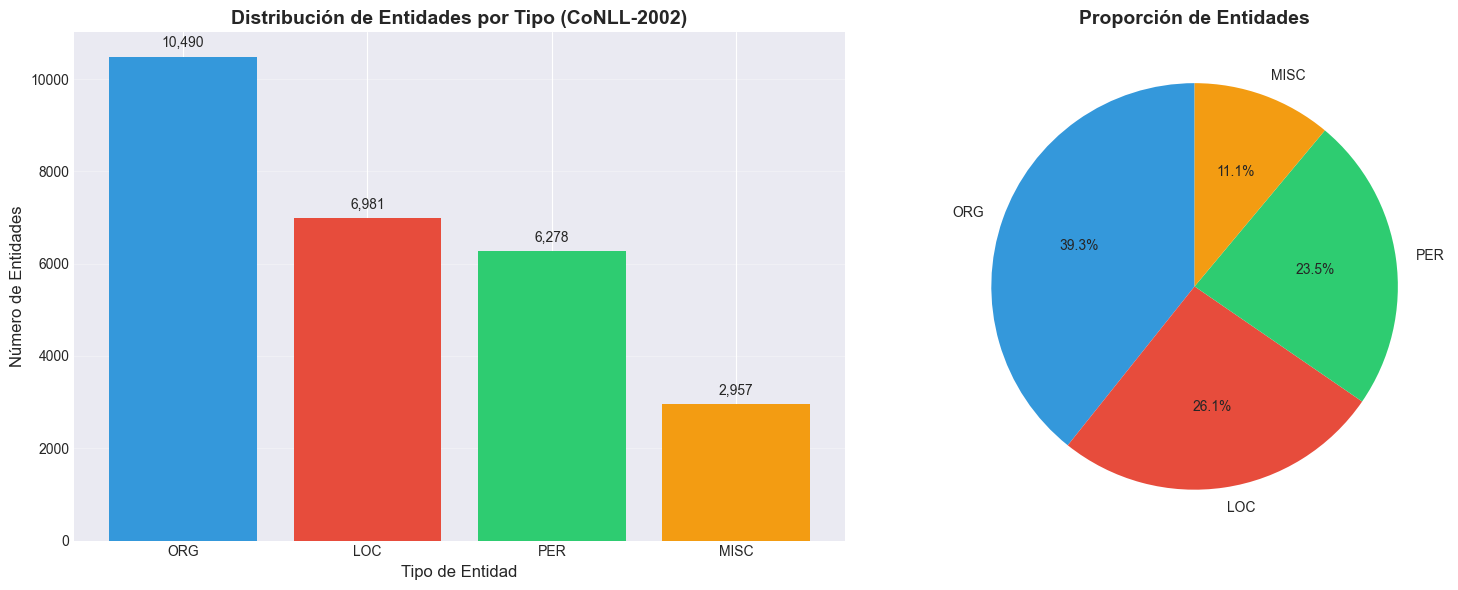

In [9]:
# Gráfico 1: Distribución de Entidades por Tipo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras por tipo
entity_stats_sorted = entity_stats.sort_values('Total', ascending=False)
axes[0].bar(entity_stats_sorted['Tipo_Entidad'], entity_stats_sorted['Total'], 
            color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_xlabel('Tipo de Entidad', fontsize=12)
axes[0].set_ylabel('Número de Entidades', fontsize=12)
axes[0].set_title('Distribución de Entidades por Tipo (CoNLL-2002)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for i, (tipo, total) in enumerate(zip(entity_stats_sorted['Tipo_Entidad'], entity_stats_sorted['Total'])):
    axes[0].text(i, total + 200, f'{total:,}', ha='center', fontsize=10)

# Pie chart
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
axes[1].pie(entity_stats_sorted['Total'], labels=entity_stats_sorted['Tipo_Entidad'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporción de Entidades', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distribucion_entidades_conll2002.png', dpi=300, bbox_inches='tight')
print(f'Gráfico guardado: {RESULTS_DIR / "distribucion_entidades_conll2002.png"}')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_25836\1128043089.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Train', 'Valid', 'Test'])


Gráfico guardado: ..\resultados\fase4_ner_bilstm\distribucion_longitudes_conll2002.png


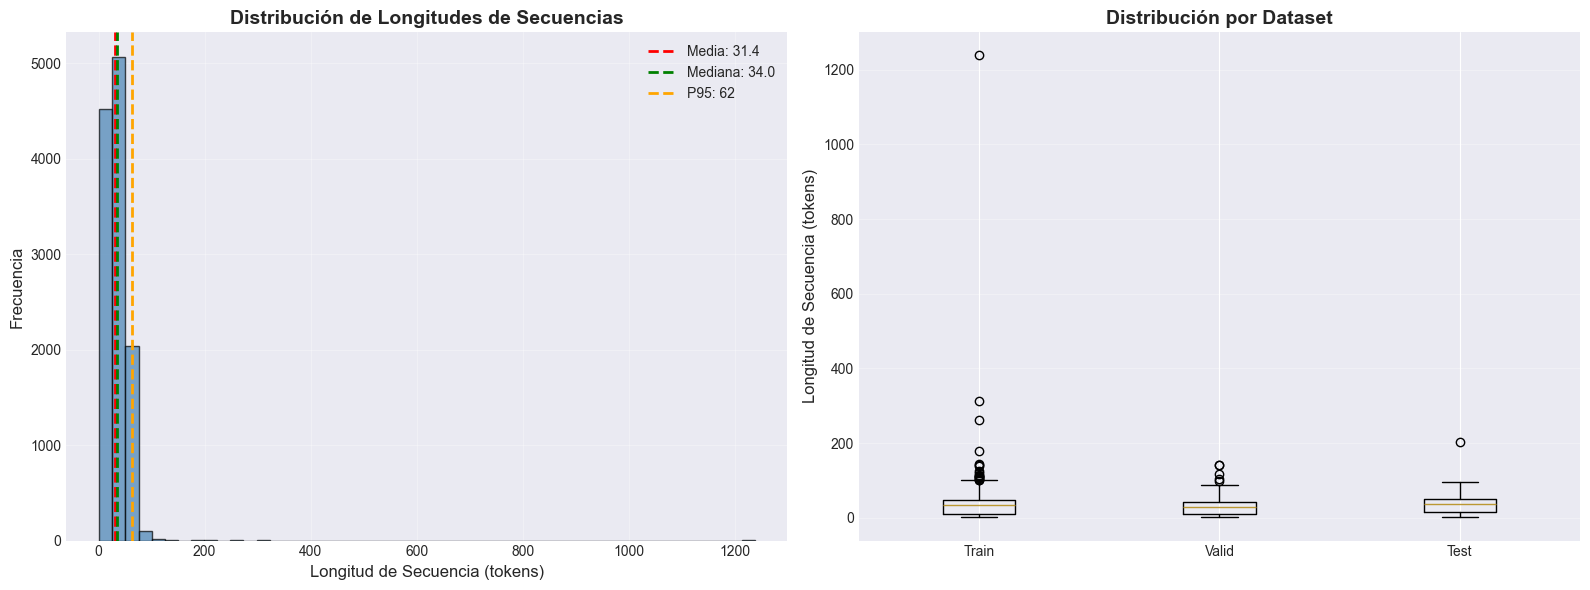

In [10]:
# Gráfico 2: Distribución de Longitudes de Secuencias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(all_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(all_lengths), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(all_lengths):.1f}')
axes[0].axvline(np.median(all_lengths), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(all_lengths):.1f}')
axes[0].axvline(p95, color='orange', linestyle='--', linewidth=2, label=f'P95: {p95}')
axes[0].set_xlabel('Longitud de Secuencia (tokens)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Longitudes de Secuencias', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot por dataset
data_to_plot = [train_lengths, valid_lengths, test_lengths]
axes[1].boxplot(data_to_plot, labels=['Train', 'Valid', 'Test'])
axes[1].set_ylabel('Longitud de Secuencia (tokens)', fontsize=12)
axes[1].set_title('Distribución por Dataset', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distribucion_longitudes_conll2002.png', dpi=300, bbox_inches='tight')
print(f'Gráfico guardado: {RESULTS_DIR / "distribucion_longitudes_conll2002.png"}')
plt.show()

Gráfico guardado: ..\resultados\fase4_ner_bilstm\comparacion_splits_conll2002.png


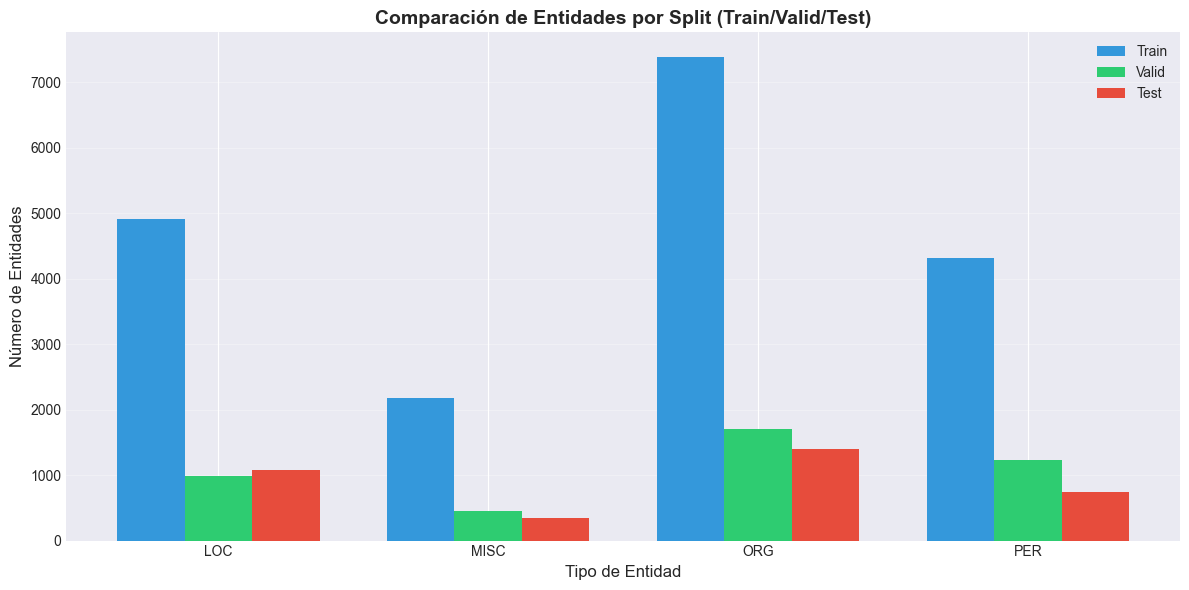

In [11]:
# Gráfico 3: Comparación Train/Valid/Test por Entidad
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(entity_types))
width = 0.25

ax.bar(x - width, entity_stats['Train'], width, label='Train', color='#3498db')
ax.bar(x, entity_stats['Valid'], width, label='Valid', color='#2ecc71')
ax.bar(x + width, entity_stats['Test'], width, label='Test', color='#e74c3c')

ax.set_xlabel('Tipo de Entidad', fontsize=12)
ax.set_ylabel('Número de Entidades', fontsize=12)
ax.set_title('Comparación de Entidades por Split (Train/Valid/Test)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(entity_types)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparacion_splits_conll2002.png', dpi=300, bbox_inches='tight')
print(f'Gráfico guardado: {RESULTS_DIR / "comparacion_splits_conll2002.png"}')
plt.show()

## 9. Ejemplos de Entidades Extraídas

In [12]:
# Extraer ejemplos de cada tipo de entidad
entity_examples = defaultdict(list)

for sentence in train_sentences[:1000]:  # Primeras 1000 oraciones
    entities = extract_entities(sentence)
    for entity_text, ent_type in entities:
        if len(entity_examples[ent_type]) < 10:  # 10 ejemplos por tipo
            entity_examples[ent_type].append(entity_text)

print('Ejemplos de Entidades Extraídas:\n')
for ent_type in sorted(entity_examples.keys()):
    print(f'{ent_type} ({len(entity_examples[ent_type])} ejemplos):')
    for i, example in enumerate(entity_examples[ent_type][:5], 1):
        print(f'  {i}. {example}')
    print()

Ejemplos de Entidades Extraídas:

LOC (10 ejemplos):
  1. Melbourne
  2. Australia
  3. Victoria
  4. Australia
  5. Victoria

MISC (10 ejemplos):
  1. Ley
  2. CrimeNet
  3. CrimeNet
  4. Ciudad
  5. Ciudad

ORG (10 ejemplos):
  1. EFE
  2. Tribunal Supremo
  3. Commonwealth
  4. EFE
  5. Izquierda Unida de Santander

PER (10 ejemplos):
  1. Abogado General del Estado
  2. Daryl Williams
  3. Abogado General
  4. Abogado General
  5. Rob Hulls



## 10. Resumen y Recomendaciones

In [13]:
# Generar resumen JSON
summary = {
    'dataset': 'CoNLL-2002 Spanish NER',
    'total_sentences': len(train_sentences) + len(valid_sentences) + len(test_sentences),
    'splits': {
        'train': len(train_sentences),
        'valid': len(valid_sentences),
        'test': len(test_sentences)
    },
    'entity_types': entity_types,
    'total_entities': int(entity_stats['Total'].sum()),
    'entity_distribution': entity_stats.set_index('Tipo_Entidad')['Total'].to_dict(),
    'sequence_stats': {
        'min_length': int(np.min(all_lengths)),
        'max_length': int(np.max(all_lengths)),
        'mean_length': float(np.mean(all_lengths)),
        'median_length': float(np.median(all_lengths)),
        'p95_length': p95,
        'p99_length': p99
    },
    'recommendations': {
        'max_length': p95,
        'reason': f'Covers ~95% of sequences ({p95} tokens)',
        'balanced': 'No - LOC and PER are more frequent',
        'class_weights': 'Consider using class weights for MISC'
    }
}

# Guardar resumen
with open(RESULTS_DIR / 'conll2002_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('RESUMEN DEL ANÁLISIS EXPLORATORIO')
print('='*60)
print(f'\nDataset: {summary["dataset"]}')
print(f'Total de oraciones: {summary["total_sentences"]:,}')
print(f'Total de entidades: {summary["total_entities"]:,}')
print(f'\nTipos de entidades: {summary["entity_types"]}')
print(f'\nLongitud de secuencias:')
print(f'  Media: {summary["sequence_stats"]["mean_length"]:.2f} tokens')
print(f'  Mediana: {summary["sequence_stats"]["median_length"]:.2f} tokens')
print(f'  P95: {summary["sequence_stats"]["p95_length"]} tokens')
print(f'\nRecomendaciones para entrenamiento:')
print(f'  max_length = {summary["recommendations"]["max_length"]} tokens')
print(f'  Razón: {summary["recommendations"]["reason"]}')
print(f'  Balance: {summary["recommendations"]["balanced"]}')
print(f'  Pesos de clase: {summary["recommendations"]["class_weights"]}')
print(f'\nArchivos generados en: {RESULTS_DIR}')
print(f'  - conll2002_tag_distribution.csv')
print(f'  - conll2002_entity_distribution.csv')
print(f'  - conll2002_sequence_lengths.csv')
print(f'  - conll2002_summary.json')
print(f'  - 3 gráficos PNG')
print('\nExploración completada correctamente')

RESUMEN DEL ANÁLISIS EXPLORATORIO

Dataset: CoNLL-2002 Spanish NER
Total de oraciones: 11,755
Total de entidades: 26,706

Tipos de entidades: ['LOC', 'MISC', 'ORG', 'PER']

Longitud de secuencias:
  Media: 31.41 tokens
  Mediana: 34.00 tokens
  P95: 62 tokens

Recomendaciones para entrenamiento:
  max_length = 62 tokens
  Razón: Covers ~95% of sequences (62 tokens)
  Balance: No - LOC and PER are more frequent
  Pesos de clase: Consider using class weights for MISC

Archivos generados en: ..\resultados\fase4_ner_bilstm
  - conll2002_tag_distribution.csv
  - conll2002_entity_distribution.csv
  - conll2002_sequence_lengths.csv
  - conll2002_summary.json
  - 3 gráficos PNG

Exploración completada correctamente
